### Context & Objectives
This project focuses on detecting fraudulent financial transactions in near real time.\
Fraud is a highly imbalanced problem where a small number of events can cause disproportionate harm. The goal is to identify suspicious behaviour early while minimising disruption to legitimate users.\
This notebook emphasises time-aware feature engineering, appropriate evaluation for imbalanced data, and production-style modelling decisions.

In [ ]:
!pip install -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score

import lightgbm as lgb
from xgboost import XGBClassifier, plot_importance

In [ ]:
# Download PaySim dataset from Kaggle
import kagglehub
path = kagglehub.dataset_download("ealaxi/paysim1")
print("Path to dataset files:", path)

In [2]:
# Load dataset
df = pd.read_csv("data/PS_20174392719_1491204439457_log.csv")

# Sanity checks
df.head()
# df.shape
# df.dtypes

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Exploratory Data Analysis

In [3]:
# Check for missing/duplicate values
df.isnull().sum()
# df.duplicated().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

💡No missing values detected, as expected for a simulated dataset.

In [4]:
# Check for class imbalance
# df["isFraud"].value_counts()
df["isFraud"].value_counts(normalize=True) # Show as %


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

💡Fraud class is highly imbalanced, consistent with real-world transaction data -> check PR AUC as well as ROC AUC.

In [5]:
# Check for distribution of fraud rate by type
df.groupby("type")["isFraud"].mean().sort_values(ascending=False)


type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

💡Fraud is not uniformly distributed across transaction types. It's much higher in TRANSFER/CASH_OUT than in PAYMENT.\
💡Therefore "type" is an important signal to help the model learn.

In [6]:
# Check amount distribution
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


💡Summary statistics show that fraudulent transactions have a higher average and upper-range amount, though substantial overlap remains.

<Axes: xlabel='step'>

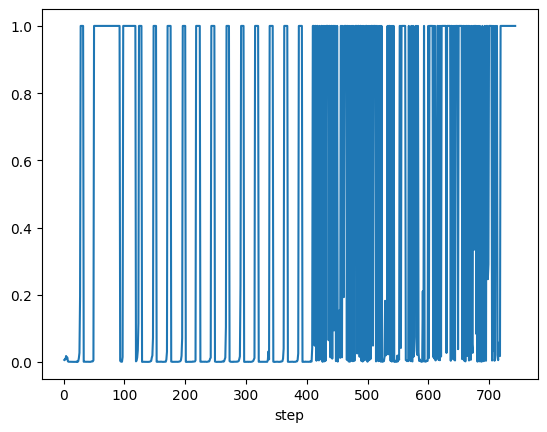

In [7]:
# Check fraud distribution over time
df.groupby("step")["isFraud"].mean().plot()

💡Fraud pattern and frequency can evolve over time, like in reality.

### Feature Engineering

In [8]:
# group by nameOrig, then count the number of rows, sort by the count descending, and show top 10
df.groupby("nameOrig").size().sort_values(ascending=False).head(10)

nameOrig
C1832548028    3
C1530544995    3
C1065307291    3
C1902386530    3
C1784010646    3
C1462946854    3
C1677795071    3
C1976208114    3
C1999539787    3
C2051359467    3
dtype: int64

In [9]:
# Sort by Origin and Time

# Define rolling window size (e.g., last 3 transactions)
window = 3 # PaySim only has as many as 3 transactions per account. In real life this would be larger

# df = df.sort_values("step").reset_index(drop=True)
df = df.sort_values(["nameOrig", "step"]).reset_index(drop=True)

# Cast "type" as category
df["type"] = df["type"].astype("category")

# Log transform amount
df["log_amount"] = np.log1p(df["amount"]) #Handles zeros safely

# Calculate amount to balance ratio (signal for attempt to drain account)
df["amount_to_balance_ratio"] = (df["amount"] / (df["oldbalanceOrg"] + 1))

# Add transaction counts by NameOrig in the last time step (burst pattern), and the last 5 steps (sustained suspicious behaviour)
# df["tx_count_last_1_step"] = (df.groupby("nameOrig").apply(lambda x: x.set_index("step")["amount"].rolling(window=1, min_periods=1).count()).reset_index(level=0, drop=True))
# df["tx_count_last_5_steps"] = (df.groupby("nameOrig").apply(lambda x: x.set_index("step")["amount"].rolling(window=5, min_periods=1).count()).reset_index(level=0, drop=True))
df["tx_count_last_1_step"] = (df.groupby("nameOrig")["step"].transform(lambda x: x.rolling(window=1, min_periods=1).count()))
df["tx_count_last_5_steps"] = (df.groupby("nameOrig")["step"].transform(lambda x: x.rolling(window=5, min_periods=1).count()))

# Add (log) amount average and deviation (“Much larger than normal” behaviour)
df["avg_amount_last_x"] = (df.groupby("nameOrig")["amount"].transform(lambda x: x.rolling(window=window, min_periods=1).mean()))
df["amount_vs_recent_avg"] = (df["amount"] / (df["avg_amount_last_x"] + 1))
# df["avg_log_amount_last_x"] = (df.groupby("nameOrig")["log_amount"].rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True))
# df["log_amount_vs_recent_avg"] = df["log_amount"] - df["avg_log_amount_last_x"]

# Add cash out/transfer ratio in last x transactions (Fraud often concentrates in these actions)
df["is_cash_out_or_transfer"] = df["type"].isin(["CASH_OUT", "TRANSFER"]).astype(int)
df["risky_tx_ratio_last_x"] = (df.groupby("nameOrig")["is_cash_out_or_transfer"].rolling(window=window, min_periods=1).mean().reset_index(level=0, drop=True))

# Add destination risk factors
# df["dest_tx_count_last_x"] = (df.groupby("nameDest")["amount"].rolling(window=window, min_periods=1).count().reset_index(level=0, drop=True))
# df["dest_unique_senders_last_x"] = (df.groupby("nameDest")["nameOrig"].rolling(window=window, min_periods=1).nunique().reset_index(level=0, drop=True))

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,amount_to_balance_ratio,tx_count_last_1_step,tx_count_last_5_steps,avg_amount_last_x,amount_vs_recent_avg,is_cash_out_or_transfer,risky_tx_ratio_last_x
0,249,CASH_OUT,244486.46,C1000000639,8946.00,0.00,C785826240,526950.37,771436.84,0,0,12.406919,27.326082,1.0,1.0,244486.46,0.999996,1,1.0
1,217,PAYMENT,3170.28,C1000001337,58089.00,54918.72,M216466820,0.00,0.00,0,0,8.061891,0.054575,1.0,1.0,3170.28,0.999685,0,0.0
2,46,PAYMENT,8424.74,C1000001725,783.00,0.00,M1974356374,0.00,0.00,0,0,9.039047,10.745842,1.0,1.0,8424.74,0.999881,0,0.0
3,231,CASH_IN,261877.19,C1000002591,7596.00,269473.19,C503690069,1126627.70,864750.51,0,0,12.475635,34.471132,1.0,1.0,261877.19,0.999996,0,0.0
4,167,CASH_IN,20528.65,C1000003372,2302074.12,2322602.77,C1840417793,82696.17,62167.52,0,0,9.929625,0.008917,1.0,1.0,20528.65,0.999951,0,0.0


### Model Training

In [ ]:
# Drop the high-cardinality IDs, fraud flag (based on simple rule of amount >200k, doesn't add meaningful signal)
df_model = df.drop(columns=["nameOrig", "nameDest", "isFlaggedFraud"])

# Sort by time
df_model = df_model.sort_values("step").reset_index(drop=True)

# Consider dropping raw time step

# Split data to get 70% for training, 15% for validation, and 15% for testing & simulation
n = len(df_model)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df_model.iloc[:train_end]
val_df   = df_model.iloc[train_end:val_end]
test_df  = df_model.iloc[val_end:]

In [ ]:
# Separate features and target
TARGET = "isFraud"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [ ]:
# Train LightGBM model - high speed and strong performance in tabular data, with good handling of class imbalance and support for early stopping
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train) # Reference ensures consistent binning between train & validation

params = {
    "objective": "binary",
    "metric": ["auc", "aucpr"],
    "boosting_type": "gbdt", # Gradient Boosting Decision Tree - classic, well-rounded choice for tabular data, with sequential tree-building and each tree correcting previous errors
    "learning_rate": 0.05, # How much each tree contributes. Small LR means more trees and smoother learning. Larger LR means fewer trees, faster learning, but higher overfit risk
    "num_leaves": 64, # Model complexity - more leaves can capture more complex patterns, but may overfit. 64 leaves is 6-7 depth
    "max_depth": -1, # Avoids unnecessary constraints early on. Let the model decide depth
    "min_data_in_leaf": 200, # Min samples per leaf to prevent the model from creating rules based on very few fraud samples. Forces generalisable patterns. Important
    "feature_fraction": 0.8, # Randomly select 80% of features for each iteration to prevent overfitting and improve generalization
    "bagging_fraction": 0.8, # Randomly select 80% of data for each iteration to prevent overfitting and improve generalization
    "bagging_freq": 5, #
    "is_unbalance": True, # important for imbalanced datasets
    "verbosity": -1 # Suppress LightGBM's own logging since we'll use callbacks
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50), # Stop training if validation AUC doesn't improve for 50 rounds
    lgb.log_evaluation(period=50) # Log evaluation results every 50 rounds
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000, # Max number of trees. Set a high number but rely on early stopping to find the optimal number
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.968717	val's auc: 0.978111
Early stopping, best iteration is:
[1]	train's auc: 0.999552	val's auc: 0.999791


In [13]:
# Make predictions and evaluate on validation set
val_preds = model.predict(X_val)
print("Validation ROC AUC:", roc_auc_score(y_val, val_preds))

# Also check PR AUC - important for imbalanced datasets
print("Validation PR AUC:", average_precision_score(y_val, val_preds))

Validation ROC AUC: 0.9990129268318253
Validation PR AUC: 0.2301717089125102


💡Extremely high ROC AUC expected here due to synthetic rule-based fraud generation; in real-world fraud this would drop materially.\
💡Given a fraud base rate of 0.1%, a PR AUC of 0.23 represents a very large lift over random, indicating the model strongly concentrates fraudulent transactions near the top of the ranking.

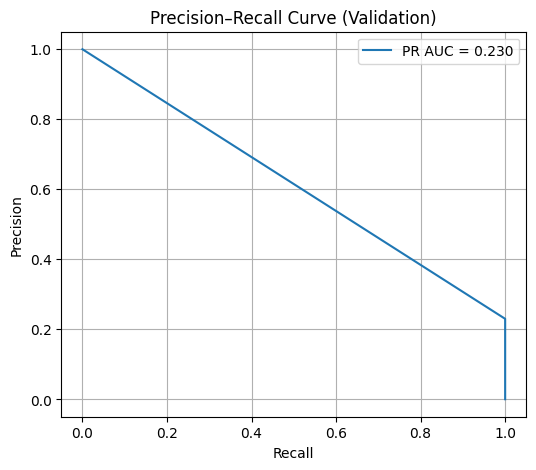

In [14]:
# Show Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, val_preds)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {average_precision_score(y_val, val_preds):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Validation)")
plt.legend()
plt.grid(True)
plt.show()

💡But the Precision–Recall curve appears almost step-like rather than smooth. This is likely because it was constructed from only a few distinct risk scores, instead of a smooth continuous spectrum of scores.\
💡This can happen when we have highly imbalanced data, and very sharp, rule-like fraud patterns in simulated data. The model learned only a few strong discriminative signals, tested a handful of fraud probability scores, quickly saturated, and assigned these almost identical scores to most transactions.\
💡Global scores such as ROC-AUC can look deceivingly good because it only cares about ranking, not spacing. PR-AUC also does not require well-calibrated probabilities to "look good". This does not mean the model is broken. The ranking is still good, but threshold granularity is too coarse to be used in actual fraud detection.

### Diagnosing Step-like PR Curve

In [15]:
# Check unique score values and number of trees to understand model behavior and complexity
print("Count of unique score values:", np.unique(val_preds).shape)
print("Unique score values:", np.unique(val_preds))
print("Number of trees:", model.current_iteration())

Count of unique score values: (6,)
Unique score values: [7.77413712e-04 7.77413712e-04 7.77413712e-04 7.77828118e-04
 7.77964536e-04 1.00000000e+00]
Number of trees: 1


💡Upon further checking, the model only split once, trained one tree, produced 6 unique scores, and stopped learning.

In [16]:
# Retrain LightGBM model, forcing more complex trees and faster learning to capture more of the rare fraud patterns
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train) # Reference ensures consistent binning between train & validation

params = {
    "objective": "binary",
    "metric": ["auc", "aucpr"],
    "boosting_type": "gbdt",

    "learning_rate": 0.1, # Higher learning rate to encourage more aggressive learning and faster convergence, especially since we are allowing more complex trees with smaller leaves. This can help the model capture the rare fraud patterns better, but we will rely on early stopping to prevent overfitting.
    "num_leaves": 16, # Since fraud rate is 0.1%, when num_leaves is large, most leaves would be empty or homogeneous (only 0s), and the model prefers not to grow rather than create useless leaves. So we try smaller leaves + more trees.
    "max_depth": 6,

    "min_data_in_leaf": 20, # allow rare-event splits
    "min_gain_to_split": 1e-6, # The model will not split further unless gain > min_gain_to_split. Explicitly setting a low bar

    "feature_fraction": 1.0, # 0.8 might have been too cautious and caused some features to be dropped at the feature pre-filter step, which worsened performance
    "bagging_fraction": 1.0,

    "scale_pos_weight": (len(y_train) - y_train.sum()) / y_train.sum(), # Forcing model to care about minority class
    # "feature_pre_filter": False, # Some features were dropped at the feature pre-filter step at last round of training. Include this to bring them back
    "feature_pre_filter": False,
    "verbosity": -1
}

callbacks = [
    lgb.early_stopping(stopping_rounds=30),
    lgb.log_evaluation(period=30)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=300, # Max number of trees. Set a high number but rely on early stopping to find the optimal number
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    callbacks=callbacks
)

# Evaluate on validation set
val_preds = model.predict(X_val)
print("Validation ROC AUC:", roc_auc_score(y_val, val_preds))

# Also check PR AUC - important for imbalanced datasets
print("Validation PR AUC:", average_precision_score(y_val, val_preds))

print("Unique values:", np.unique(val_preds).shape)
print("Current Iterations:", model.current_iteration())

Training until validation scores don't improve for 30 rounds
[30]	train's auc: 0.998983	val's auc: 0.999179
Early stopping, best iteration is:
[5]	train's auc: 0.998938	val's auc: 0.99935
Validation ROC AUC: 0.9988719182414046
Validation PR AUC: 0.20736885346322584
Unique values: (26,)
Current Iterations: 5


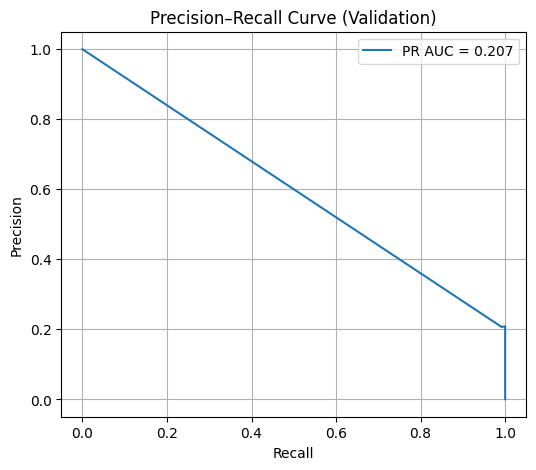

In [17]:
# Show Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, val_preds)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {average_precision_score(y_val, val_preds):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Validation)")
plt.legend()
plt.grid(True)
plt.show()

💡Tuning and forcing the model to learn more of the rare fraud patterns lead to 5 trees and 26 unique scores. The PR curve is still near linear. In real-life scenarios we need more fine-grained probability estimates to draw our thresholds.\
💡The model behaves this way because tree growth in LightGBM is leaf-wise which is faster but more aggresive (compared to e.g. XGBoost). It also pre-bins features into histograms, searches for splits between bins instead of individual values (hence faster). When this meets extreme signals in simulated data, it results in very early stopping and coarse output granularity.

### Switching to XGBoost

In [31]:
# Try XGBoost instead, one-hot encoding the "type" feature since XGBoost doesn't handle categorical features natively.
df_model_xgb = df_model.copy()
df_model_xgb = pd.get_dummies(df_model_xgb, columns=["type"], drop_first=True) # One-hot encode "type" feature

# Sort by time (again, just to be sure)
df_model_xgb = df_model_xgb.sort_values("step").reset_index(drop=True)

# Split data to get 70% for traiing, 15% for testing, and 15% for production simulation
n = len(df_model_xgb)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df_model_xgb.iloc[:train_end]
val_df   = df_model_xgb.iloc[train_end:val_end]
test_df  = df_model_xgb.iloc[val_end:]

X_train = train_df.drop(columns=[TARGET,'step']) # Consider dropping raw time step
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[TARGET ,'step'])
y_val = val_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

In [19]:
# Train XGBoost model instead
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
    eval_metric="aucpr",
    tree_method="hist", # Fast histogram-based algorithm for large datasets, similar to LightGBM's approach
    random_state=42,
    min_child_weight=20, # Similar to LightGBM's min_data_in_leaf, prevents creating leaves based on very few fraud samples
    gamma=1e-6 # Similar to LightGBM's min_gain_to_split, prevents splitting unless it improves AUC by at least this amount
)

model_xgb.fit(X_train, y_train)

# Evaluate on validation set
xgb_preds = model_xgb.predict_proba(X_val)[:, 1]
print("Validation ROC AUC:", roc_auc_score(y_val, xgb_preds))

# Also check PR AUC - important for imbalanced datasets
print("Validation PR AUC:", average_precision_score(y_val, xgb_preds))

Validation ROC AUC: 0.9999002944639624
Validation PR AUC: 0.904785214843584


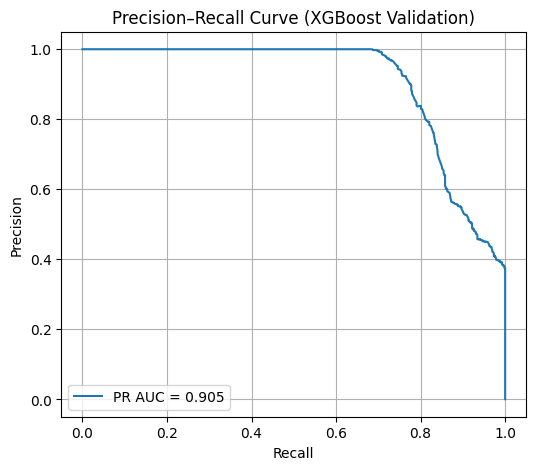

In [20]:
# Show Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_val, xgb_preds)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {average_precision_score(y_val, xgb_preds):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost Validation)")
plt.legend()
plt.grid(True)
plt.show()

💡XGBoost grows trees level-wise which is more conservative, keeps refining and results in more fine-grained outputs.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

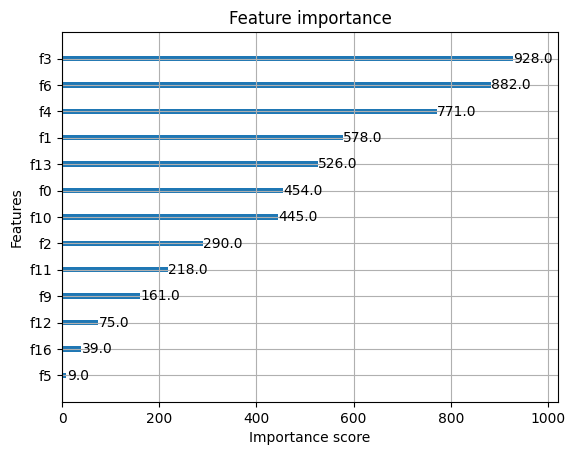

In [21]:
# Check feature importance
plot_importance(model_xgb)

💡Upon checking features importance, native features tend to be more important than our temporal/velocity features.

### Benchmarking with Native Features Only

In [23]:
FEATURES = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "type"
] # Dropping time step, accout IDs, and fraud flag

TARGET = "isFraud"

df_small = df[FEATURES + [TARGET]].copy()

# One-hot encode transaction type
df_small = pd.get_dummies(df_small, columns=["type"], drop_first=True)

X_b = df_small.drop(columns=[TARGET])
y_b = df_small[TARGET]

# 80:20 split with stratification to maintain class balance
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42, stratify=y_b
)

In [24]:
# Helper function to evaluate model performance
def evaluate_model(name, y_true, y_scores, threshold=0.5):
    print(f"\n===== {name} =====")

    print("ROC AUC:", roc_auc_score(y_true, y_scores))
    print("PR AUC :", average_precision_score(y_true, y_scores))
    # print("Unique score values:", np.unique(y_scores).shape)

    y_pred = (y_scores >= threshold).astype(int)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=3))

    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR Curve – {name}")
    plt.grid(True)
    plt.show()


===== XGBoost =====
ROC AUC: 0.9998906651268662
PR AUC : 0.9424774192217865

Confusion Matrix:
[[1267505    3376]
 [      3    1640]]

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.997     0.999   1270881
           1      0.327     0.998     0.493      1643

    accuracy                          0.997   1272524
   macro avg      0.663     0.998     0.746   1272524
weighted avg      0.999     0.997     0.998   1272524



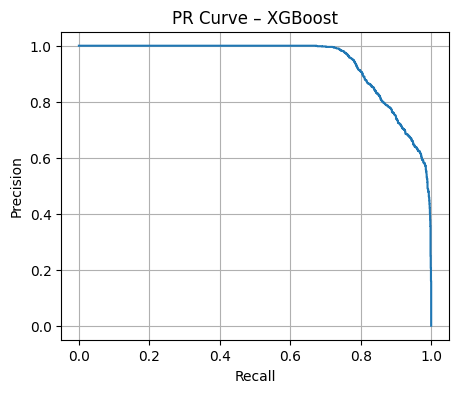

In [25]:
# Train XGBoost with similar parameters and evaluate
model_xgb_b = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42
)

model_xgb_b.fit(X_train_b, y_train_b)

xgb_preds_b = model_xgb_b.predict_proba(X_val_b)[:, 1]

evaluate_model("XGBoost", y_val_b, xgb_preds_b)

💡Using only native features, XGBoost achieved PR-AUC of 0.94.\
💡In PaySim, fraud is based on simple rules e.g. large amounts, draining accounts etc. Native features already capture these signals. Temporal/velocity features did not add signal, only noise.\
💡In real-world fraud detection, however, temporal/velocity features are often critical because fraud patterns evolve/manifest over sequences rather than single transactions.

### Select Threshold (for XGBoost trained on all features)

In [26]:
# Select the lowest threshold that achieves ≥99% recall on the validation set
target_recall = 0.99

# Remove last recall value (it has no threshold)
recall_vals_trimmed = recall[:-1]

# Indices where recall ≥ 99%
valid_indices = np.where(recall_vals_trimmed >= target_recall)[0]

if len(valid_indices) == 0:
    raise ValueError("No threshold achieves 99% recall")

# Choose the lowest threshold among those
selected_index = valid_indices[-1]   # last index = lowest threshold
selected_threshold = thresholds[selected_index]

print("Selected threshold:", selected_threshold)
print("Validation recall at threshold:",
    recall_score(y_val, xgb_preds >= selected_threshold))
print("Validation precision at threshold:",
    precision_score(y_val, xgb_preds >= selected_threshold))

Selected threshold: 0.99127847
Validation recall at threshold: 0.9911190053285968
Validation precision at threshold: 0.3910301331464611


In [ ]:
print("Validation fraud rate:", y_val.mean())
print("Validation data count:", len(y_val))

Validation fraud rate: 0.0005899037398639764
Validation data count: 954393


: 

💡Whether precision of 0.39 is too low is a business question.

In [ ]:
# Evaluate on test set using the selected threshold
test_probs = model_xgb.predict(X_test.drop(columns=['step']))
test_preds = (test_probs >= selected_threshold).astype(int)

test_recall_at_threshold = recall_score(y_test, test_preds)
test_precision_at_threshold = precision_score(y_test, test_preds)
test_roc_auc = roc_auc_score(y_test, test_probs)
test_pr_auc  = average_precision_score(y_test, test_probs)

print("Test Recall:", test_recall_at_threshold)
print("Test Precision:", test_precision_at_threshold)
print("Test ROC AUC:", test_roc_auc)
print("Test PR AUC:", test_pr_auc)

Test Recall: 0.9997506234413965
Test Precision: 0.7697772657450077
Test ROC AUC: 0.9992445134004421
Test PR AUC: 0.7695863491259791


In [ ]:
# Check baseline fraud rate in val vs test sets
print("Validation fraud rate:", y_val.mean())
print("Test fraud rate:", y_test.mean())

Validation fraud rate: 0.0005899037398639764
Test fraud rate: 0.004201623440238979


💡Test Precision of 0.77 is higher than Validation Precision, due to higher baseline fraud rate in the test set - there was more fraud as time goes by, but not necessarily more complex fraud patterns.\
💡This highlights the importance of monitoring of data and model performance drift, and adjustment of threshold.

### Save Data and Artifacts

In [ ]:
# Save our Train, Validation, and Test sets to file
train_df.to_csv("data/train_df.csv", index=False)
val_df.to_csv("data/val_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)

In [28]:
# Save our XGBoost model
model_xgb.save_model("artifacts/xgb_fraud_model.json")

In [ ]:
# Find optimal threshold, check classification report, and save threshold and performance metrics to file
threshold_data = {
    "threshold": float(selected_threshold),
    "selection_method": "recall_at_99pct",
    "test_recall": float(recall_score(y_test, test_preds)),
    "test_precision": float(precision_score(y_test, test_preds))
}

with open("artifacts/threshold.json", "w") as f:
    json.dump(threshold_data, f, indent=4)

In [30]:
# Save feature schema
feature_schema = {
    "feature_order": list(X_train.columns),
    "n_features": len(X_train.columns)
}

with open("artifacts/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=4)

In [34]:
# Save model metadata
metadata = {
    "model_type": "xgboost",
    "training_date_utc": datetime.utcnow().isoformat(),
    "train_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "features_used": list(X_train.columns),
    "test_roc_auc": float(test_roc_auc),
    "test_pr_auc": float(test_pr_auc),
    "notes": "Velocity features included. Time-based split."
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)


### Deployment and simulated ingestion/inference/monitoring in the next notebook. Stay tuned!